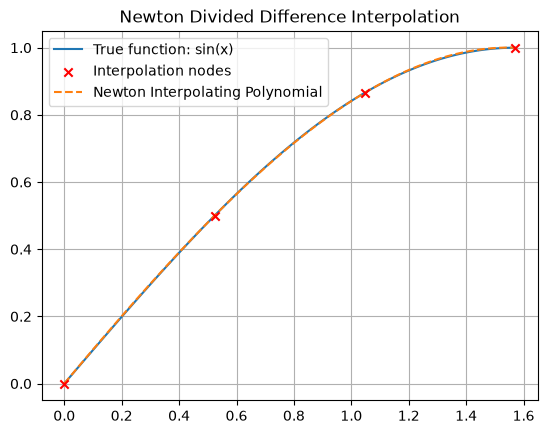

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fine grid for plotting the true function and interpolation
x = np.linspace(0, np.pi / 2, 100)
f = np.sin(x)

# Interpolation nodes and their function values
t = np.array([0, np.pi/6, 2*np.pi/6, 3*np.pi/6])
y = np.sin(t)

# --- 1. Calculate Newton Divided Difference Coefficients ---
n = len(t)
coef = np.zeros([n, n])
coef[:, 0] = y # first column is just the function values

for j in range(1, n):
    for i in range(n - j):
        coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (t[i+j] - t[i])

# The coefficients for the Newton polynomial are the top row of our table
c = coef[0, :]

# --- 2. Evaluate the Newton Interpolating Polynomial ---
P_x = np.zeros_like(x)
for i in range(len(x)):
    val = c[0]
    prod = 1.0
    for j in range(1, n):
        prod *= (x[i] - t[j-1])
        val += c[j] * prod
    P_x[i] = val

# --- 3. Plotting ---
plt.plot(x, f, label='True function: sin(x)')
plt.scatter(t, y, color='red', marker='x', label='Interpolation nodes', zorder=5)
plt.plot(x, P_x, label='Newton Interpolating Polynomial', linestyle='--')
plt.legend()
plt.title("Newton Divided Difference Interpolation")
plt.grid(True)
plt.show()
